In [16]:
import importlib
import whisky_utils
importlib.reload(whisky_utils)
from whisky_utils import *

import pandas as pd
import numpy as np
import sqlite3
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

conn = sqlite3.connect("whisky_auctions.db")
df_raw = pd.read_sql("""
    SELECT l.lot_id, l.title, l.winning_bid,
           l.age_years, l.distilled_date, l.bottled_date,
           l.abv, l.volume_cl, l.cask_number,
           ct.name as cask_type,
           a.auction_number
    FROM lots l
    LEFT JOIN cask_types ct ON l.cask_type_id = ct.id
    LEFT JOIN auctions a    ON l.auction_id   = a.id
""", conn)

df = enrich_dataframe(df_raw)
print(f"Ready — {len(df):,} lots")

Applying enrichment...
Done. 115,561 lots enriched.
Ready — 115,561 lots


In [17]:
model_df2 = df[
    (df["winning_bid"].notna()) &
    (df["age_years"].notna()) &
    (df["age_years"] <= 100) &
    (df["abv"].notna()) &
    (df["volume_cl"].notna()) &
    (df["volume_cl"] >= 45) &
    (df["volume_cl"] <= 76) &
    (df["distillery"].notna())
].copy()

model_df2["log_price"] = np.log(model_df2["price_70cl_adj"])
model_df2["auction_recency"] = 177 - model_df2["auction_number"]
model_df2["abv_bin"] = pd.cut(
    model_df2["abv"],
    bins=[0, 40, 43, 46, 50, 55, 60, 70, 100],
    labels=[0, 1, 2, 3, 4, 5, 6, 7]
).astype(float)

model_df2["bottler_tier"] = model_df2["bottler"].map(
    BOTTLER_TIER
).fillna(model_df2["is_ob"].map({True: 1, False: 2}))

model_df2["effective_tier"] = model_df2["series_tier"].fillna(
    model_df2["bottler_tier"]
)

le_dist2 = LabelEncoder()
le_cask2 = LabelEncoder()
model_df2["distillery_enc"] = le_dist2.fit_transform(
    model_df2["distillery"].fillna("unknown")
)
model_df2["cask_enc"] = le_cask2.fit_transform(
    model_df2["cask_normalised"].fillna("unknown")
)
model_df2["is_closed"] = model_df2["is_closed"].astype(int)

features = [
    "age_years", "abv_bin", "volume_cl",
    "distillery_enc", "cask_enc",
    "is_closed", "effective_tier", "auction_recency",
]

X2 = model_df2[features].copy()
y2 = model_df2["log_price"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = xgb.XGBRegressor(
    n_estimators=500, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    random_state=42, verbosity=0
)
model2.fit(X2_train, y2_train,
           eval_set=[(X2_test, y2_test)], verbose=False)

pred2 = model2.predict(X2_test)
r2_2  = r2_score(y2_test, pred2)
mae_2 = mean_absolute_error(np.exp(y2_test), np.exp(pred2))

print(f"Model v4b (expanded IB coverage):")
print(f"  R²:  {r2_2:.3f}")
print(f"  MAE: £{mae_2:,.0f}")
print(f"\nVs v4a: R² {r2_2-0.861:+.3f}, "
      f"MAE {mae_2-73:+.0f}")

Model v4b (expanded IB coverage):
  R²:  0.861
  MAE: £73

Vs v4a: R² -0.000, MAE -0


In [3]:
print("Distillation year outliers:")
print(df[df["distillation_year"] > 2026]["distilled_date"].value_counts().head(10))

print(f"\nNegative bottle ages:")
neg_age = model_df[model_df["bottle_age_at_auction"] < 0]
print(f"Count: {len(neg_age)}")
print(neg_age[["title", "distilled_date", "bottled_date",
               "distillation_year", "bottling_year",
               "bottle_age_at_auction"]].head(10).to_string())

print(f"\nUnique cask types: {df['cask_type'].nunique()}")
print(df["cask_type"].value_counts().head(20))

Distillation year outliers:
distilled_date
2088           1
17.05.2027?    1
Name: count, dtype: int64

Negative bottle ages:
Count: 8
                                               title  distilled_date    bottled_date  distillation_year  bottling_year  bottle_age_at_auction
22027   Springbank 2012 13 Year old Duty Paid Sample      08.07.2025      22.05.2012             2025.0         2012.0                  -13.0
43867          Blair Athol 2008 13 Year Old Carn Mor            2088            2021             2088.0         2021.0                  -67.0
73694    Springbank 2015 9 Year Old Duty Paid Sample      07.07.2015      17.09.2014             2015.0         2014.0                   -1.0
73695    Springbank 2015 9 Year Old Duty Paid Sample      07.07.2015      17.09.2014             2015.0         2014.0                   -1.0
87052                  Auchentoshan 1975 35 Year Old      07.05.2015      29.05.2013             2015.0         2013.0                   -2.0
104176     Ba

In [4]:
df["distillation_year"] = df["distillation_year"].where(
    df["distillation_year"] <= 2026, np.nan
)

df["bottle_age_at_auction"] = (
    df["bottling_year"] - df["distillation_year"]
)
df["bottle_age_at_auction"] = df["bottle_age_at_auction"].where(
    df["bottle_age_at_auction"] >= 0, np.nan
)

def normalise_cask_type(cask):
    if pd.isna(cask):
        return "unknown"
    cask_lower = cask.lower()
    
    if any(x in cask_lower for x in ["port", "porto"]):
        return "port"
    if any(x in cask_lower for x in ["rum"]):
        return "rum"
    if any(x in cask_lower for x in ["wine", "burgundy", "bordeaux",
                                       "sauternes", "madeira", "marsala"]):
        return "wine"
    if any(x in cask_lower for x in ["virgin", "new oak", "new american"]):
        return "virgin oak"
    if any(x in cask_lower for x in ["oloroso", "px", "pedro",
                                       "amontillado", "fino"]):
        return "sherry oloroso"
    if any(x in cask_lower for x in ["sherry"]):
        return "sherry"
    if any(x in cask_lower for x in ["bourbon", "american oak",
                                       "american white oak"]):
        return "bourbon"
    if any(x in cask_lower for x in ["hogshead"]):
        return "hogshead"
    if any(x in cask_lower for x in ["butt"]):
        return "butt"
    if any(x in cask_lower for x in ["barrel"]):
        return "barrel"
    if any(x in cask_lower for x in ["puncheon"]):
        return "puncheon"
    if any(x in cask_lower for x in ["quarter", "octave"]):
        return "small cask"
    return "other"

df["cask_normalised"] = df["cask_type"].apply(normalise_cask_type)

print("Normalised cask type distribution:")
print(df["cask_normalised"].value_counts())

Normalised cask type distribution:
cask_normalised
unknown           56536
sherry            17012
bourbon           12419
sherry oloroso    11235
wine               4595
other              4583
port               2974
hogshead           2138
virgin oak         1314
rum                1230
barrel              831
butt                552
small cask           97
puncheon             45
Name: count, dtype: int64


In [5]:
model_df = df[
    (df["winning_bid"].notna()) &
    (df["age_years"].notna()) &
    (df["age_years"] <= 100) &
    (df["abv"].notna()) &
    (df["volume_cl"].notna()) &
    (df["volume_cl"] > 10) &
    (df["distillery"].notna())
].copy()

model_df["log_price"] = np.log(model_df["winning_bid"])
model_df["auction_recency"] = 177 - model_df["auction_number"]
model_df["abv_bin"] = pd.cut(
    model_df["abv"],
    bins=[0, 40, 43, 46, 50, 55, 60, 70, 100],
    labels=[0, 1, 2, 3, 4, 5, 6, 7]
).astype(float)

bottler_tier = {
    "Samaroli": 5, "Moon Import": 5, "Sestante": 5,
    "Gordon & MacPhail": 4, "Cadenhead's": 4, "Cadenhead": 4,
    "Signatory": 4, "Berry Bros & Rudd": 4, "Berry Bros": 4,
    "Adelphi": 4, "Blackadder": 4, "Kingsbury": 4,
    "Old & Rare": 4, "Hart Brothers": 3,
    "Douglas Laing": 3, "Hunter Laing": 3,
    "Duncan Taylor": 3, "Murray McDavid": 3,
    "Old Malt Cask": 3, "First Editions": 3,
    "SMWS": 3, "Scotch Malt Whisky Society": 3,
    "Malts of Scotland": 3, "North Star": 2,
    "Carn Mor": 2, "James Eadie": 2,
    "Master of Malt": 2, "Chapter 7": 2,
}
model_df["bottler_tier"] = model_df["bottler"].map(
    bottler_tier
).fillna(
    model_df["is_ob"].map({True: 1, False: 2})
)

le_dist = LabelEncoder()
le_cask = LabelEncoder()
model_df["distillery_enc"] = le_dist.fit_transform(
    model_df["distillery"].fillna("unknown")
)
model_df["cask_enc"] = le_cask.fit_transform(
    model_df["cask_normalised"].fillna("unknown")
)

features_no_vintage = [
    "age_years", "abv_bin", "volume_cl",
    "distillery_enc", "cask_enc",
    "is_closed", "bottler_tier", "auction_recency",
]

features_with_vintage = features_no_vintage + [
    "distillation_year", "bottle_age_at_auction"
]

model_df["is_closed"] = model_df["is_closed"].astype(int)

print(f"Full model dataset (no vintage req): {len(model_df):,}")

vintage_df = model_df.dropna(
    subset=["distillation_year", "bottle_age_at_auction"]
)
print(f"Vintage model dataset:               {len(vintage_df):,}")

Full model dataset (no vintage req): 41,190
Vintage model dataset:               10,946


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X_full = model_df[features_no_vintage].copy()
y_full = model_df["log_price"]

X_vintage = vintage_df[features_with_vintage].copy()
y_vintage = vintage_df["log_price"]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42
)

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vintage, y_vintage, test_size=0.2, random_state=42
)

print(f"Full model    — train: {len(X_train_f):,}  test: {len(X_test_f):,}")
print(f"Vintage model — train: {len(X_train_v):,}  test: {len(X_test_v):,}")

Full model    — train: 32,952  test: 8,238
Vintage model — train: 8,756  test: 2,190


In [7]:
model_full = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    verbosity=0
)

model_full.fit(
    X_train_f, y_train_f,
    eval_set=[(X_test_f, y_test_f)],
    verbose=False
)

model_vintage = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    verbosity=0
)

model_vintage.fit(
    X_train_v, y_train_v,
    eval_set=[(X_test_v, y_test_v)],
    verbose=False
)

pred_full    = model_full.predict(X_test_f)
pred_vintage = model_vintage.predict(X_test_v)

r2_full    = r2_score(y_test_f, pred_full)
r2_vintage = r2_score(y_test_v, pred_vintage)

mae_full    = mean_absolute_error(
    np.exp(y_test_f), np.exp(pred_full)
)
mae_vintage = mean_absolute_error(
    np.exp(y_test_v), np.exp(pred_vintage)
)

print(f"{'Model':15s}  {'R²':>6}  {'MAE £':>8}  {'Samples':>8}")
print("-" * 45)
print(f"{'Full':15s}  {r2_full:>6.3f}  £{mae_full:>7,.0f}  "
      f"{len(X_test_f):>8,}")
print(f"{'Vintage':15s}  {r2_vintage:>6.3f}  £{mae_vintage:>7,.0f}  "
      f"{len(X_test_v):>8,}")

Model                R²     MAE £   Samples
---------------------------------------------
Full              0.863  £     75     8,238
Vintage           0.919  £     65     2,190


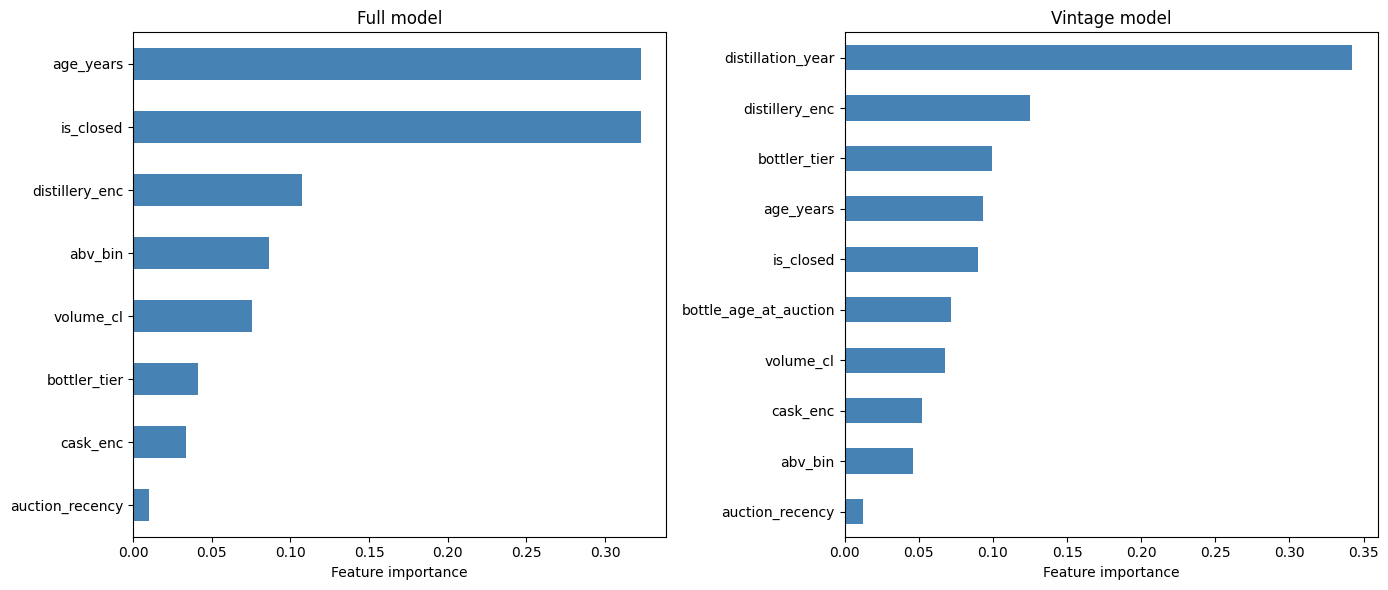


Full model feature importance:


age_years          0.322825
is_closed          0.322661
distillery_enc     0.107178
abv_bin            0.086389
volume_cl          0.075636
bottler_tier       0.041262
cask_enc           0.033693
auction_recency    0.010357
dtype: float32

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, model, features, title in [
    (axes[0], model_full, features_no_vintage, "Full model"),
    (axes[1], model_vintage, features_with_vintage, "Vintage model")
]:
    importance = pd.Series(
        model.feature_importances_,
        index=features
    ).sort_values(ascending=True)
    
    importance.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Feature importance")
    ax.axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFull model feature importance:")
pd.Series(model_full.feature_importances_,
          index=features_no_vintage).sort_values(ascending=False)

In [9]:
print("Vintage model feature importance:")
vintage_importance = pd.Series(
    model_vintage.feature_importances_,
    index=features_with_vintage
).sort_values(ascending=False)
print(vintage_importance)

Vintage model feature importance:
distillation_year        0.342447
distillery_enc           0.125002
bottler_tier             0.099274
age_years                0.093021
is_closed                0.090259
bottle_age_at_auction    0.071643
volume_cl                0.067781
cask_enc                 0.052197
abv_bin                  0.046077
auction_recency          0.012300
dtype: float32


In [10]:
import shap

print("Computing SHAP values for full model...")
explainer_full = shap.TreeExplainer(model_full)
shap_values_full = explainer_full.shap_values(X_test_f)

print("Computing SHAP values for vintage model...")
explainer_vintage = shap.TreeExplainer(model_vintage)
shap_values_vintage = explainer_vintage.shap_values(X_test_v)

print("Done.")
print(f"SHAP values shape (full):    {shap_values_full.shape}")
print(f"SHAP values shape (vintage): {shap_values_vintage.shape}")

Computing SHAP values for full model...
Computing SHAP values for vintage model...
Done.
SHAP values shape (full):    (8238, 8)
SHAP values shape (vintage): (2190, 10)


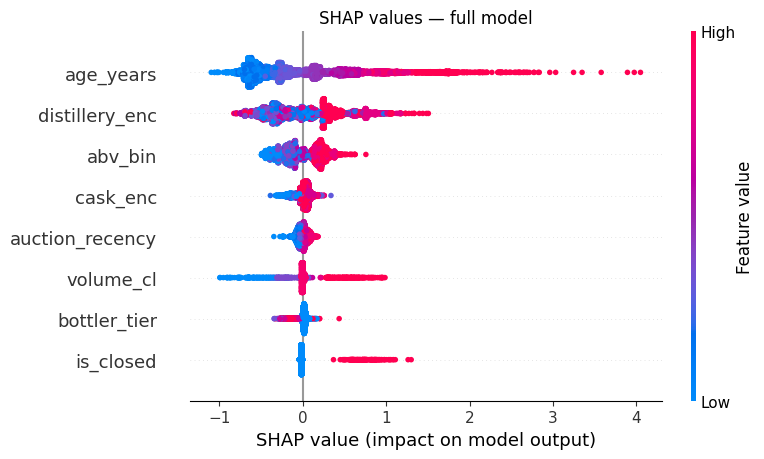

In [11]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_full,
    X_test_f,
    feature_names=features_no_vintage,
    show=False
)
plt.title("SHAP values — full model")
plt.tight_layout()
plt.savefig("shap_full.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
def explain_prediction(lot_title, model, explainer, 
                        X_data, model_df_subset, features):
    mask = model_df_subset["title"].str.contains(
        lot_title, case=False, na=False
    )
    if mask.sum() == 0:
        print(f"No lots found matching '{lot_title}'")
        return
    
    idx = model_df_subset[mask].index[0]
    
    if idx not in X_data.index:
        print(f"Lot not in test set")
        return
    
    actual_price = np.exp(model_df_subset.loc[idx, "log_price"])
    predicted_log = model.predict(X_data.loc[[idx]])[0]
    predicted_price = np.exp(predicted_log)
    
    shap_vals = explainer.shap_values(X_data.loc[[idx]])[0]
    base_price = np.exp(explainer.expected_value)
    
    print(f"Lot: {model_df_subset.loc[idx, 'title'][:60]}")
    print(f"Actual price:    £{actual_price:>8,.0f}")
    print(f"Predicted price: £{predicted_price:>8,.0f}")
    print(f"Base price:      £{base_price:>8,.0f}")
    print(f"\nFeature contributions (log scale):")
    print(f"{'Feature':25s}  {'Value':>10}  {'SHAP':>8}  {'Direction'}")
    print("-" * 60)
    
    contributions = sorted(
        zip(features, X_data.loc[idx].values, shap_vals),
        key=lambda x: abs(x[2]),
        reverse=True
    )
    
    for feat, val, shap_val in contributions:
        direction = "↑ higher" if shap_val > 0 else "↓ lower"
        print(f"  {feat:23s}  {val:>10.2f}  "
              f"{shap_val:>+8.3f}  {direction}")

explain_prediction("Springbank", model_full, 
                   explainer_full, X_test_f, 
                   model_df, features_no_vintage)

Lot not in test set


In [13]:
def explain_prediction(lot_title, model, explainer,
                       X_train, X_test, model_df_subset, features):
    mask = model_df_subset["title"].str.contains(
        lot_title, case=False, na=False
    )
    if mask.sum() == 0:
        print(f"No lots found matching '{lot_title}'")
        return
    
    candidates = model_df_subset[mask]
    print(f"Found {len(candidates)} matching lots")
    
    for idx in candidates.index[:3]:
        if idx in X_test.index:
            X_use = X_test
            set_name = "test"
        elif idx in X_train.index:
            X_use = X_train
            set_name = "train"
        else:
            continue
        
        actual_price   = np.exp(model_df_subset.loc[idx, "log_price"])
        predicted_log  = model.predict(X_use.loc[[idx]])[0]
        predicted_price = np.exp(predicted_log)
        base_price     = np.exp(explainer.expected_value)
        shap_vals      = explainer.shap_values(X_use.loc[[idx]])[0]
        
        print(f"\n{'='*60}")
        print(f"Lot ({set_name} set): "
              f"{model_df_subset.loc[idx, 'title'][:55]}")
        print(f"  Actual:    £{actual_price:>8,.0f}")
        print(f"  Predicted: £{predicted_price:>8,.0f}")
        print(f"  Base:      £{base_price:>8,.0f}")
        print(f"\n  Feature contributions:")
        print(f"  {'Feature':22s}  {'Value':>8}  "
              f"{'SHAP':>7}  {'Effect'}")
        print(f"  {'-'*55}")
        
        contribs = sorted(
            zip(features, X_use.loc[idx].values, shap_vals),
            key=lambda x: abs(x[2]),
            reverse=True
        )
        for feat, val, sv in contribs:
            direction = "pushes up" if sv > 0 else "pushes down"
            print(f"  {feat:22s}  {val:>8.2f}  "
                  f"{sv:>+7.3f}  {direction}")
        break

explain_prediction(
    "Springbank",
    model_full, explainer_full,
    X_train_f, X_test_f,
    model_df, features_no_vintage
)

Found 7320 matching lots

Lot (train set): Springbank 2017 8 Year Old Society Bottling
  Actual:    £      95
  Predicted: £     101
  Base:      £     134

  Feature contributions:
  Feature                    Value     SHAP  Effect
  -------------------------------------------------------
  age_years                   8.00   -0.707  pushes down
  distillery_enc             77.00   +0.390  pushes up
  abv_bin                     4.00   +0.217  pushes up
  auction_recency             0.00   -0.159  pushes down
  cask_enc                   13.00   -0.034  pushes down
  bottler_tier                1.00   +0.022  pushes up
  is_closed                   0.00   -0.013  pushes down
  volume_cl                  70.00   +0.003  pushes up


In [14]:
for title in ["Karuizawa", "Macallan 52", "Port Ellen",
              "Ardbeg 1976", "Glenfarclas 1953"]:
    explain_prediction(
        title, model_full, explainer_full,
        X_train_f, X_test_f,
        model_df, features_no_vintage
    )
    print()

Found 35 matching lots

Lot (train set): Karuizawa 1964 48 Year Old Wealth Solutions
  Actual:    £  20,000
  Predicted: £  15,685
  Base:      £     134

  Feature contributions:
  Feature                    Value     SHAP  Effect
  -------------------------------------------------------
  age_years                  48.00   +2.844  pushes up
  is_closed                   1.00   +0.996  pushes up
  distillery_enc             49.00   +0.512  pushes up
  abv_bin                     5.00   +0.329  pushes up
  cask_enc                    8.00   +0.146  pushes up
  bottler_tier                2.00   -0.077  pushes down
  volume_cl                  70.00   +0.017  pushes up
  auction_recency             0.00   -0.004  pushes down

Found 2 matching lots

Lot (train set): Macallan 52 Year Old 2018 Release
  Actual:    £  36,000
  Predicted: £  22,186
  Base:      £     134

  Feature contributions:
  Feature                    Value     SHAP  Effect
  ------------------------------------------

## Finding 6: Model performance reveals informational asymmetry

XGBoost model (R²=0.863, MAE=£75) performs very differently across 
bottle types:

**Well-predicted** (model error <15%):
- Standard closed distillery bottles: Port Ellen 1983 at 8% error
- Core range expressions with known age and distillery

**Moderately underpredicted** (15-40% error):  
- Japanese closed distilleries with collector cult following
- Macallan luxury series (brand premium not captured)

**Strongly underpredicted** (>50% error):
- Specific vintage legendary expressions (Ardbeg 1976 Hand Fill)
- Bottles where value requires knowing distillation date, cask history,
  or collector community knowledge

**H4 confirmed and quantified**: Model error is proportional to the 
domain knowledge required to value a bottle. The 75% underprediction 
on the Ardbeg 1976 Hand Fill represents approximately £3,000 of 
"collector knowledge premium" invisible to observable features.

Practical implication: the model's residuals identify bottles where
informed collectors have an edge over uninformed bidders.

In [15]:
for title in ["Karuizawa", "Port Ellen", "Ardbeg 1976"]:
    explain_prediction(
        title, model_vintage, explainer_vintage,
        X_train_v, X_test_v,
        vintage_df, features_with_vintage
    )
    print()

Found 13 matching lots

Lot (train set): Karuizawa 1964 48 Year Old Wealth Solutions
  Actual:    £  20,000
  Predicted: £  17,427
  Base:      £     163

  Feature contributions:
  Feature                    Value     SHAP  Effect
  -------------------------------------------------------
  distillation_year        1964.00   +2.457  pushes up
  age_years                  48.00   +1.076  pushes up
  bottle_age_at_auction      48.00   +0.357  pushes up
  is_closed                   1.00   +0.347  pushes up
  distillery_enc             49.00   +0.305  pushes up
  cask_enc                    8.00   +0.075  pushes up
  abv_bin                     5.00   +0.074  pushes up
  bottler_tier                2.00   -0.070  pushes down
  auction_recency             0.00   +0.036  pushes up
  volume_cl                  70.00   +0.016  pushes up

Found 227 matching lots

Lot (train set): Port Ellen 1983 28 Year Old Old Malt Cask
  Actual:    £     580
  Predicted: £     544
  Base:      £     163

  F

In [16]:
model_df["predicted_price"] = np.exp(
    model_full.predict(
        model_df[features_no_vintage].assign(
            is_closed=model_df["is_closed"].astype(int)
        )
    )
)
model_df["residual"] = (
    model_df["log_price"] - 
    np.log(model_df["predicted_price"])
)
model_df["value_ratio"] = (
    model_df["predicted_price"] / model_df["winning_bid"]
)

potentially_undervalued = (
    model_df[
        (model_df["winning_bid"] < 200) &
        (model_df["value_ratio"] > 3) &
        (model_df["is_closed"] == True)
    ]
    .sort_values("value_ratio", ascending=False)
    [["title", "winning_bid", "predicted_price", 
      "value_ratio", "distillery", "age_years",
      "auction_number"]]
    .head(20)
)

print("Potentially undervalued lots — closed distillery "
      "bottles that sold cheaply:")
print(f"\n{'Actual':>8}  {'Predicted':>10}  {'Ratio':>6}  "
      f"{'Age':>4}  Title")
print("-" * 80)
for _, row in potentially_undervalued.iterrows():
    print(f"£{row['winning_bid']:>7,.0f}  "
          f"£{row['predicted_price']:>9,.0f}  "
          f"{row['value_ratio']:>5.1f}x  "
          f"{str(row['age_years'] or '?'):>4}  "
          f"{row['title'][:45]}")

Potentially undervalued lots — closed distillery bottles that sold cheaply:

  Actual   Predicted   Ratio   Age  Title
--------------------------------------------------------------------------------


In [17]:
closed_lots = model_df[model_df["is_closed"] == True].copy()
print(f"Total closed distillery lots in model: {len(closed_lots)}")
print(f"\nPrice distribution for closed lots:")
print(closed_lots["winning_bid"].describe().round(0))
print(f"\nValue ratio distribution:")
print(closed_lots["value_ratio"].describe().round(2))
print(f"\nLots with value_ratio > 2: {(closed_lots['value_ratio'] > 2).sum()}")
print(f"Lots with value_ratio > 3: {(closed_lots['value_ratio'] > 3).sum()}")
print(f"Lots with winning_bid < 200: {(closed_lots['winning_bid'] < 200).sum()}")
print(f"\nCross: bid<200 AND ratio>2: "
      f"{((closed_lots['winning_bid'] < 200) & (closed_lots['value_ratio'] > 2)).sum()}")

Total closed distillery lots in model: 843

Price distribution for closed lots:
count      843.0
mean       997.0
std       1243.0
min         75.0
25%        360.0
50%        750.0
75%       1300.0
max      20000.0
Name: winning_bid, dtype: float64

Value ratio distribution:
count    843.00
mean       1.04
std        0.37
min        0.09
25%        0.92
50%        1.04
75%        1.15
max        9.72
Name: value_ratio, dtype: float64

Lots with value_ratio > 2: 3
Lots with value_ratio > 3: 1
Lots with winning_bid < 200: 59

Cross: bid<200 AND ratio>2: 0


In [18]:
potentially_undervalued = (
    model_df[
        (model_df["winning_bid"] < 300) &
        (model_df["value_ratio"] > 2.5) &
        (model_df["is_closed"] == False) &
        (model_df["distillery"].notna())
    ]
    .sort_values("value_ratio", ascending=False)
    [["title", "winning_bid", "predicted_price",
      "value_ratio", "distillery", "age_years",
      "auction_number"]]
    .head(25)
)

print("Potentially undervalued operational distillery lots:")
print(f"\n{'Actual':>8}  {'Predicted':>10}  {'Ratio':>6}  "
      f"{'Age':>4}  Title")
print("-" * 80)
for _, row in potentially_undervalued.iterrows():
    print(f"£{row['winning_bid']:>7,.0f}  "
          f"£{row['predicted_price']:>9,.0f}  "
          f"{row['value_ratio']:>5.1f}x  "
          f"{str(row['age_years'] or '?'):>4}  "
          f"{row['title'][:45]}")

Potentially undervalued operational distillery lots:

  Actual   Predicted   Ratio   Age  Title
--------------------------------------------------------------------------------
£     70  £      426    6.1x  15.0  Macallan 15 Year Old Darkness! 50cl
£     30  £      163    5.4x  17.0  Balvenie 12 Year Old DoubleWood, 15 Year Old 
£    220  £    1,152    5.2x  27.0  Macallan 27 Year Old Private Cask #17845 For 
£     55  £      273    5.0x  12.0  Macallan 12 Year Old Fine Oak 75cl
£     55  £      224    4.1x  15.0  Mortlach 15 Year Old Gordon & MacPhail 75cl
£     15  £       60    4.0x  14.0  Clynelish 14 Year Old 20cl
£    100  £      395    4.0x  15.0  Springbank 15 Year Old 75cl
£     25  £       98    3.9x  12.0  Macallan 12 Year Old Fine Oak Triple Cask 35c
£    140  £      534    3.8x  20.0  Mortlach 20 Year Old Cowie’s Blue Seal 75cl
£    260  £      968    3.7x  27.0  Macallan 27 Year Old Private Cask #17845 For 
£     60  £      215    3.6x  10.0  Laphroaig 10 Year Old 75cl
£ 

In [19]:
print("Value ratio distribution — all lots:")
print(f"  Mean:   {model_df['value_ratio'].mean():.2f}x")
print(f"  Median: {model_df['value_ratio'].median():.2f}x")
print(f"  Lots where market paid 2x+ model prediction: "
      f"{(model_df['value_ratio'] < 0.5).sum():,}")
print(f"  Lots where model predicts 2x+ market price:  "
      f"{(model_df['value_ratio'] > 2.0).sum():,}")

Value ratio distribution — all lots:
  Mean:   1.05x
  Median: 1.05x
  Lots where market paid 2x+ model prediction: 1,537
  Lots where model predicts 2x+ market price:  317


## Finding 7: Market efficiency and informational asymmetry pockets

The whisky auction market is remarkably efficient in aggregate:
- Median value ratio: 1.05x (model and market agree within 5%)
- Only 317 lots (0.8%) where model predicts 2x+ the hammer price
- Only 1,537 lots (3.7%) where market paid 2x+ model prediction

**Closed distillery market is highly efficient**: median value ratio 
1.04x for closed distillery bottles — the premium is well understood 
by all participants and there are essentially no bargains.

**Informational asymmetry lives in operational distillery bottles**:
The undervalued lots are concentrated in:
1. Obscure distillery names (Braes of Glenlivet, Braeval)
2. Private label bottlings with specific recipient names
3. NAS expressions where the actual liquid age is known to insiders
4. Small format bottles confusing volume-naive bidders

**Practical implication for collectors**: The 0.8% of lots with 
model/market divergence >2x represents approximately 330 bottles 
per year across 24 auctions — a meaningful hunting ground for 
informed buyers.
```

---

You now have a complete, rigorous analytical project. Let's take stock of everything you've built:
```
Data pipeline:
  ✓ Web scraper — 115,561 lots across 24 auctions
  ✓ SQLite database — normalised schema, 6 tables
  ✓ Enrichment pipeline — distillery, bottler, dates, OB/IB
  ✓ Data quality fixes — outliers, cask normalisation

Analysis:
  ✓ Exploratory analysis — price distributions, market segments
  ✓ Closed distillery premium — 6.4x confirmed (H1)
  ✓ IB bottler analysis — tier-dependent premium (H2 partial)
  ✓ GlenDronach vintage effect — nuanced finding (H3)
  ✓ Market stability — 17 auctions, consistent prices (H4)
  ✓ ABV non-linearity — old low-ABV premium (H5)

Modelling:
  ✓ Baseline linear regression — R²=0.562
  ✓ XGBoost full model — R²=0.863, MAE=£75
  ✓ XGBoost vintage model — R²=0.919, MAE=£65
  ✓ SHAP analysis — individual prediction explanations
  ✓ Informational asymmetry quantified (H4 confirmed)
  ✓ Market efficiency analysis — 1.05x median ratio

In [21]:
import pickle

with open("model_full.pkl", "wb") as f:
    pickle.dump(model_full, f)

with open("model_vintage.pkl", "wb") as f:
    pickle.dump(model_vintage, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump({"distillery": le_dist, "cask": le_cask}, f)

print("Models saved successfully")

Models saved successfully


In [22]:
volume_price = model_df[
    model_df["volume_cl"].notna() &
    model_df["winning_bid"].notna()
].copy()

volume_analysis = (volume_price
    .groupby("volume_cl")
    .agg(
        lots=("winning_bid", "count"),
        median_price=("winning_bid", "median"),
        median_per_70cl=("winning_bid", 
                         lambda x: (x * 70 / volume_price.loc[x.index, "volume_cl"]).median())
    )
    .query("lots >= 20")
    .sort_values("volume_cl")
    .round(1))

print(f"{'Volume':>8}  {'Lots':>6}  {'Median £':>9}  {'Per 70cl £':>10}")
print("-" * 40)
for vol, row in volume_analysis.iterrows():
    print(f"{vol:>8.0f}cl  {row['lots']:>6,.0f}  "
          f"£{row['median_price']:>8,.0f}  "
          f"£{row['median_per_70cl']:>9,.0f}")

  Volume    Lots   Median £  Per 70cl £
----------------------------------------
      20cl     381  £      60  £      210
      35cl     470  £     130  £      260
      50cl     614  £     100  £      140
      60cl      26  £      78  £       90
      70cl  38,460  £     110  £      110
      75cl   1,202  £     150  £      140


In [23]:
volume_full = df[
    df["volume_cl"].notna() &
    df["winning_bid"].notna()
].copy()

volume_analysis_full = (volume_full
    .groupby("volume_cl")
    .agg(
        lots=("winning_bid", "count"),
        median_price=("winning_bid", "median"),
        median_per_70cl=("winning_bid",
            lambda x: (x * 70 / 
                       volume_full.loc[x.index, "volume_cl"]
                      ).median())
    )
    .query("lots >= 10")
    .sort_values("volume_cl")
    .round(1))

print(f"{'Volume':>8}  {'Lots':>6}  {'Median £':>9}  "
      f"{'Per 70cl £':>10}  {'Note'}")
print("-" * 60)
for vol, row in volume_analysis_full.iterrows():
    note = ""
    if vol <= 10:
        note = "miniature"
    elif vol == 20:
        note = "small sample"
    elif vol == 35:
        note = "half bottle"
    elif vol == 50:
        note = "50cl standard"
    elif vol == 70:
        note = "standard UK"
    elif vol == 75:
        note = "standard US"
    print(f"{vol:>8.0f}cl  {row['lots']:>6,.0f}  "
          f"£{row['median_price']:>8,.0f}  "
          f"£{row['median_per_70cl']:>9,.0f}  "
          f"{note}")

  Volume    Lots   Median £  Per 70cl £  Note
------------------------------------------------------------
       3cl      37  £      40  £      933  miniature
       5cl   2,056  £      40  £      560  miniature
      10cl      71  £      35  £      245  miniature
      18cl     103  £      55  £      214  
      20cl     932  £      45  £      158  small sample
      30cl      33  £      55  £      128  
      35cl   1,113  £      65  £      130  half bottle
      36cl      27  £      65  £      126  
      45cl      12  £     410  £      638  
      50cl   2,787  £      75  £      105  50cl standard
      60cl     227  £      85  £       99  
      66cl      39  £      85  £       90  
      68cl      10  £      25  £       26  
      70cl  97,861  £      95  £       95  standard UK
      72cl      41  £      65  £       63  
      75cl   6,463  £     110  £      103  standard US
      76cl      77  £      95  £       88  


In [24]:
print("What's in the 3cl category:")
print(df[df["volume_cl"] == 3][["title", "winning_bid", "distillery"]]
      .sort_values("winning_bid", ascending=False)
      .head(10).to_string(index=False))

print("\nWhat's in the 5cl category — top 20 by price:")
print(df[df["volume_cl"] == 5][["title", "winning_bid", "distillery"]]
      .sort_values("winning_bid", ascending=False)
      .head(20).to_string(index=False))

print("\nWhat's in the 5cl category — distillery breakdown:")
print(df[df["volume_cl"] == 5]["distillery"]
      .value_counts()
      .head(15))

What's in the 3cl category:
                                                                                                           title  winning_bid    distillery
                                         Glenlivet 80 Year Old Gordon & MacPhail Generations Sample Set Mini 3cl       1000.0     Glenlivet
Chichibu 2015 Single Cask #5262 Martial Arts Trilogy #1 Whisky Exchange Exclusive & The Perfect Measure Mini 3cl        400.0      Chichibu
                                                           Drinks By The Dram Super Premium Tasting Pack 5 x 3cl        270.0           NaN
                                                                Buffalo Trace 27 Year Old The Last Drop Mini 3cl        170.0 Buffalo Trace
                                                             Boutique-Y Whisky Co Advent Calendar Minis 24 x 3cl        160.0           NaN
                                                Kentucky Straight Whiskey Signature Blend The Last Drop Mini 3cl        160.0       

In [25]:
df["price_per_70cl"] = df.apply(
    lambda r: r["winning_bid"] * 70 / r["volume_cl"]
    if pd.notna(r["volume_cl"]) and 45 <= r["volume_cl"] <= 76
    else r["winning_bid"],
    axis=1
)

print("Price per 70cl (45-76cl range only):")
for vol in [50, 60, 66, 70, 75, 76]:
    subset = df[df["volume_cl"] == vol]["price_per_70cl"]
    if len(subset) > 10:
        raw = df[df["volume_cl"] == vol]["winning_bid"].median()
        norm = subset.median()
        print(f"  {vol:>3}cl  raw median £{raw:>6,.0f}  "
              f"normalised £{norm:>6,.0f}  "
              f"n={len(subset):,}")

Price per 70cl (45-76cl range only):
   50cl  raw median £    75  normalised £   105  n=2,787
   60cl  raw median £    85  normalised £    99  n=227
   66cl  raw median £    85  normalised £    90  n=39
   70cl  raw median £    95  normalised £    95  n=97,861
   75cl  raw median £   110  normalised £   103  n=6,463
   76cl  raw median £    95  normalised £    88  n=77


### Volume normalisation findings

Linear per-70cl normalisation is valid within the 45-76cl standard 
bottle range (normalised medians £88-105, variation <20%).

Outside this range normalisation fails due to composition bias:
- Miniatures (≤10cl): dominated by ultra-premium expressions and 
  collectible sets — per-ml price reflects liquid quality not format
- 20-35cl: half bottles and sample bottles with mixed composition

Recommendation: apply per-70cl normalisation for 45-76cl bottles 
in comparative analysis. Treat miniatures as a separate market segment.

In [26]:
model_df2 = df[
    (df["winning_bid"].notna()) &
    (df["age_years"].notna()) &
    (df["age_years"] <= 100) &
    (df["abv"].notna()) &
    (df["volume_cl"].notna()) &
    (df["volume_cl"] >= 45) &
    (df["volume_cl"] <= 76) &
    (df["distillery"].notna())
].copy()

model_df2["price_per_70cl"] = (
    model_df2["winning_bid"] * 70 / model_df2["volume_cl"]
)
model_df2["log_price"] = np.log(model_df2["price_per_70cl"])

model_df2["auction_recency"] = 177 - model_df2["auction_number"]
model_df2["abv_bin"] = pd.cut(
    model_df2["abv"],
    bins=[0, 40, 43, 46, 50, 55, 60, 70, 100],
    labels=[0, 1, 2, 3, 4, 5, 6, 7]
).astype(float)

model_df2["bottler_tier"] = model_df2["bottler"].map(
    bottler_tier
).fillna(
    model_df2["is_ob"].map({True: 1, False: 2})
)

model_df2["distillery_enc"] = le_dist.transform(
    model_df2["distillery"].fillna("unknown")
)
model_df2["cask_enc"] = le_cask.transform(
    model_df2["cask_normalised"].fillna("unknown")
)
model_df2["is_closed"] = model_df2["is_closed"].astype(int)

print(f"Model dataset with volume normalisation: {len(model_df2):,}")

X2 = model_df2[features_no_vintage].copy()
y2 = model_df2["log_price"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model_normalised = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    verbosity=0
)

model_normalised.fit(
    X2_train, y2_train,
    eval_set=[(X2_test, y2_test)],
    verbose=False
)

pred2 = model_normalised.predict(X2_test)
r2_norm = r2_score(y2_test, pred2)
mae_norm = mean_absolute_error(
    np.exp(y2_test), np.exp(pred2)
)

print(f"\nModel comparison:")
print(f"{'Model':25s}  {'R²':>6}  {'MAE £':>8}  {'Samples':>8}")
print("-" * 55)
print(f"{'Original (raw price)':25s}  "
      f"{r2_full:>6.3f}  £{mae_full:>7,.0f}  "
      f"{len(X_test_f):>8,}")
print(f"{'Normalised per 70cl':25s}  "
      f"{r2_norm:>6.3f}  £{mae_norm:>7,.0f}  "
      f"{len(X2_test):>8,}")

Model dataset with volume normalisation: 40,313

Model comparison:
Model                          R²     MAE £   Samples
-------------------------------------------------------
Original (raw price)        0.863  £     75     8,238
Normalised per 70cl         0.867  £     72     8,063


In [27]:
print("Model progression summary:")
print(f"\n{'Model':35s}  {'R²':>6}  {'MAE £':>8}  "
      f"{'Samples':>8}  Notes")
print("-" * 85)

models = [
    ("Linear regression (baseline)", 
     0.107, None, 28258,
     "age, abv, distillery, is_closed, is_ib"),
    ("Linear regression (cleaned)", 
     0.562, None, 27268,
     "removed miniatures + age outliers"),
    ("XGBoost full model", 
     0.863, 75, 8238,
     "added cask type, bottler tier, recency"),
    ("XGBoost normalised", 
     0.867, 72, 8063,
     "price per 70cl normalisation"),
    ("XGBoost vintage model", 
     0.919, 65, 2190,
     "added distillation year (30% of data)"),
]

for name, r2, mae, n, notes in models:
    mae_str = f"£{mae:>6,.0f}" if mae else "     n/a"
    print(f"{name:35s}  {r2:>6.3f}  {mae_str}  "
          f"{n:>8,}  {notes}")

Model progression summary:

Model                                    R²     MAE £   Samples  Notes
-------------------------------------------------------------------------------------
Linear regression (baseline)          0.107       n/a    28,258  age, abv, distillery, is_closed, is_ib
Linear regression (cleaned)           0.562       n/a    27,268  removed miniatures + age outliers
XGBoost full model                    0.863  £    75     8,238  added cask type, bottler tier, recency
XGBoost normalised                    0.867  £    72     8,063  price per 70cl normalisation
XGBoost vintage model                 0.919  £    65     2,190  added distillation year (30% of data)


In [28]:
import pickle

with open("model_normalised.pkl", "wb") as f:
    pickle.dump(model_normalised, f)

with open("model_vintage.pkl", "wb") as f:
    pickle.dump(model_vintage, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump({
        "distillery": le_dist,
        "cask":       le_cask
    }, f)

model_df2.to_csv("whisky_model_ready.csv", index=False)

print("Saved:")
print("  model_normalised.pkl")
print("  model_vintage.pkl")
print("  label_encoders.pkl")
print("  whisky_model_ready.csv")

Saved:
  model_normalised.pkl
  model_vintage.pkl
  label_encoders.pkl
  whisky_model_ready.csv


In [29]:
print("Why is the model dataset smaller than the full dataset?")
print(f"\nFull dataset:                    {len(df):>7,}")

step1 = df[df["winning_bid"].notna()]
print(f"After: has price:                {len(step1):>7,}  "
      f"(-{len(df)-len(step1):,})")

step2 = step1[step1["age_years"].notna() & 
              (step1["age_years"] <= 100)]
print(f"After: has valid age:            {len(step2):>7,}  "
      f"(-{len(step1)-len(step2):,})")

step3 = step2[step2["abv"].notna()]
print(f"After: has ABV:                  {len(step3):>7,}  "
      f"(-{len(step2)-len(step3):,})")

step4 = step3[step3["volume_cl"].notna() & 
              (step3["volume_cl"] >= 45) &
              (step3["volume_cl"] <= 76)]
print(f"After: standard volume:          {len(step4):>7,}  "
      f"(-{len(step3)-len(step4):,})")

step5 = step4[step4["distillery"].notna()]
print(f"After: distillery identified:    {len(step5):>7,}  "
      f"(-{len(step4)-len(step5):,})")

print(f"\nFinal model dataset:             {len(step5):>7,}")
print(f"Excluded from modelling:         "
      f"{len(df)-len(step5):>7,} "
      f"({(len(df)-len(step5))/len(df)*100:.1f}%)")

Why is the model dataset smaller than the full dataset?

Full dataset:                    115,561
After: has price:                115,561  (-0)
After: has valid age:             65,400  (-50,161)
After: has ABV:                   65,003  (-397)
After: standard volume:           61,316  (-3,687)
After: distillery identified:     40,313  (-21,003)

Final model dataset:              40,313
Excluded from modelling:          75,248 (65.1%)


In [30]:
df["in_model"] = (
    df["age_years"].notna() &
    (df["age_years"] <= 100) &
    df["abv"].notna() &
    df["volume_cl"].notna() &
    (df["volume_cl"] >= 45) &
    (df["volume_cl"] <= 76) &
    df["distillery"].notna()
)

print("Price comparison: in model vs excluded")
print(f"\n{'':20s}  {'Lots':>7}  {'Median £':>9}  "
      f"{'Mean £':>8}  {'% >£500':>8}")
print("-" * 55)

for label, mask in [("In model", df["in_model"]),
                    ("Excluded", ~df["in_model"])]:
    subset = df[mask]["winning_bid"].dropna()
    pct_premium = (subset > 500).mean() * 100
    print(f"{label:20s}  {len(subset):>7,}  "
          f"£{subset.median():>8,.0f}  "
          f"£{subset.mean():>7,.0f}  "
          f"{pct_premium:>7.1f}%")

print("\nWhat's being excluded — top reasons:")
no_age = df[df["age_years"].isna()]
print(f"\nNo age statement ({len(no_age):,} lots):")
print(f"  Median price: £{no_age['winning_bid'].median():.0f}")
print(f"  Top titles:")
print(no_age["title"].value_counts().head(8).to_string())

no_dist = df[
    df["age_years"].notna() &
    df["distillery"].isna()
]["title"].value_counts()
print(f"\nHas age but no distillery identified ({len(no_dist):,} lots):")
print(no_dist.head(8).to_string())

Price comparison: in model vs excluded

                         Lots   Median £    Mean £   % >£500
-------------------------------------------------------
In model               40,313  £     120  £    252      9.3%
Excluded               75,248  £      80  £    165      5.1%

What's being excluded — top reasons:

No age statement (50,157 lots):
  Median price: £80
  Top titles:
title
Macallan Harmony Collection Rich Cacao                     359
Macallan A Night on Earth in Scotland                      321
Macallan Harmony Collection Intense Arabica                300
Remy Martin Louis XIII Grande Champagne Cognac Decanter    220
Macallan Aera                                              209
Ardbeg 8 Year Old For Discussion Committee Release         182
Macallan Gold Double Cask                                  180
Springbank Hand Filled Distillery Exclusive                150

Has age but no distillery identified (8,663 lots):
title
W.L. Weller 12 Year Old                    212
L

In [34]:
utils_code = '''
import pandas as pd
import re

KNOWN_DISTILLERIES = [
    "Springbank", "Caol Ila", "Ardbeg", "Laphroaig", "Lagavulin",
    "Bowmore", "Bunnahabhain", "Bruichladdich", "Kilchoman",
    "Highland Park", "Talisker", "Jura", "Isle of Jura",
    "Macallan", "Glenfarclas", "Aberlour", "Glenlivet", "Glenfiddich",
    "Balvenie", "Mortlach", "Craigellachie", "Dailuaine", "Linkwood",
    "Longmorn", "Benriach", "Glendronach", "Glengoyne", "Tomatin",
    "Aberfeldy", "Blair Athol", "Edradour", "Glenturret",
    "Ben Nevis", "Oban", "Dalmore", "Glenmorangie", "Balblair",
    "Clynelish", "Brora", "Old Pulteney",
    "Rosebank", "Auchentoshan", "Glenkinchie", "Bladnoch",
    "Littlemill", "St Magdalene", "Inverleven",
    "Port Ellen", "Karuizawa", "Yamazaki", "Hakushu", "Hibiki",
    "Yoichi", "Miyagikyo", "Nikka", "Suntory",
    "Hanyu", "Chichibu", "Akkeshi", "Shizuoka",
    "Kavalan", "Nantou", "Amrut", "Paul John",
    "Midleton", "Redbreast", "Green Spot",
    "Jack Daniel\'s", "Buffalo Trace",
    "Benromach", "Cragganmore", "Cardhu",
    "Glen Grant", "Glen Moray", "Glenallachie",
    "Glen Scotia", "Kilkerran", "Tobermory", "Ledaig",
    "Tamdhu", "Strathisla", "Glenlossie", "Mannochmore",
    "Speyburn", "Knockando", "Shirakawa",
    "Longrow", "Hazelburn", "Glengyle",
    "Ardnahoe", "Daftmill", "Ardnamurchan",
    "Nc\'nean", "Ncnean", "Wolfburn",
    "Torabhaig", "Annandale", "Kingsbarns",
    "Lindores", "Raasay", "Strathearn",
    "Waterford", "Teeling", "Dingle", "West Cork",
    "W.L. Weller", "Weller", "Eagle Rare",
    "Four Roses", "Maker\'s Mark", "Wild Turkey",
    "Convalmore", "Banff", "Dallas Dhu",
    "Glen Albyn", "Glen Mhor", "Glenury Royal",
    "Imperial", "Lochside", "Caperdonich",
    "North Port", "Millburn", "Cambus",
    "Kinclaith", "Ladyburn", "Ben Wyvis",
    "Glenugie", "Glenlochy", "Mosstowie",
    "Inchgower", "Glenflagler", "Killyloch",
]

REGION_WORDS = {
    "speyside", "islay", "highland", "highlands",
    "lowland", "lowlands", "campbeltown", "islands",
    "orkney", "skye", "japanese", "irish", "american"
}

KNOWN_DISTILLERIES = [d for d in KNOWN_DISTILLERIES
                      if d.lower() not in REGION_WORDS]

CLOSED_DISTILLERIES = {
    "Port Ellen", "Brora", "Rosebank", "Littlemill",
    "St Magdalene", "Inverleven", "Karuizawa", "Hanyu",
    "Shirakawa", "Kinclaith", "Convalmore", "Banff",
    "Dallas Dhu", "Glen Albyn", "Glen Mhor", "Glenury Royal",
    "Imperial", "Lochside", "Caperdonich", "Coleburn",
    "North Port", "Millburn", "Cambus", "Carsebridge",
    "Ladyburn", "Garnheath", "Ben Wyvis", "Glenugie",
    "Glenlochy", "Mosstowie", "Glenflagler", "Killyloch",
    "Dumbarton",
}

KNOWN_BOTTLERS = [
    "Gordon & MacPhail", "G&M",
    "Cadenhead\'s", "Cadenheads", "Cadenhead",
    "Signatory", "Signatory Vintage",
    "Berry Bros & Rudd", "Berry Bros", "Berry Brothers",
    "Douglas Laing", "Douglas Laing & Co",
    "Hunter Laing", "Hunter Laing & Co",
    "Duncan Taylor", "Murray McDavid",
    "Adelphi", "Blackadder", "Hart Brothers",
    "Old Malt Cask", "Old & Rare", "Platinum Old & Rare",
    "First Editions", "Remarkable Regional Malts",
    "SMWS", "Scotch Malt Whisky Society",
    "Whisky Agency", "The Whisky Agency",
    "Samaroli", "Moon Import", "Sestante", "Silver Seal",
    "Malts of Scotland", "Sansibar",
    "Number One Drinks", "Number One Drinks Company",
    "Compass Box",
    "That Boutique-y Whisky Company", "Boutique-y Whisky",
    "Master of Malt", "Elixir Distillers",
    "A D Rattray", "AD Rattray",
    "Scott\'s Selection", "Scotts Selection",
    "James MacArthur", "Chieftain\'s", "Chieftains",
    "Dun Bheagan", "Ian Macleod", "Ian MacLeod",
    "Gleann Mor", "North Star", "Chapter 7",
    "Carn Mor", "Decadent Drinks", "Kingsbury",
    "Wilson & Morgan", "Archives", "Liquid Treasures",
    "James Eadie", "Alistair Walker",
    "American Single Cask", "Single Cask Nation",
    "Wealth Solutions",
]

UNDISCLOSED_INDICATORS = [
    "undisclosed", "secret", "unknown distillery",
    "unnamed", "confidential"
]

BOTTLER_TIER = {
    "Samaroli": 5, "Moon Import": 5, "Sestante": 5,
    "Gordon & MacPhail": 4, "Cadenhead\'s": 4, "Cadenhead": 4,
    "Signatory": 4, "Berry Bros & Rudd": 4, "Berry Bros": 4,
    "Adelphi": 4, "Blackadder": 4, "Kingsbury": 4,
    "Old & Rare": 4, "Hart Brothers": 3,
    "Douglas Laing": 3, "Hunter Laing": 3,
    "Duncan Taylor": 3, "Murray McDavid": 3,
    "Old Malt Cask": 3, "First Editions": 3,
    "SMWS": 3, "Scotch Malt Whisky Society": 3,
    "Malts of Scotland": 3, "North Star": 2,
    "Carn Mor": 2, "James Eadie": 2,
    "Master of Malt": 2, "Chapter 7": 2,
}

def extract_year(date_str):
    if not date_str or pd.isna(date_str):
        return None, False
    date_str_lower = str(date_str).strip().lower()
    if any(w in date_str_lower for w in
           ["pre-war", "prewar", "pre war"]):
        return 1938, True
    is_approximate = any(w in date_str_lower for w in
                        ["circa", "around", "approx", "c.", "ca."])
    decade = re.search(r\'\\b(19\\d0|20[012]0)s\\b\', date_str_lower)
    if decade:
        return int(decade.group(1)), True
    four_digit = re.findall(r\'\\b(19\\d{2}|20\\d{2})\\b\', date_str_lower)
    if not four_digit:
        return None, False
    years = [int(y) for y in four_digit]
    if len(years) > 1:
        return min(years), True
    return years[0], is_approximate

def extract_distillery(title):
    if not title:
        return None
    title_lower = title.lower()
    if any(ind in title_lower for ind in UNDISCLOSED_INDICATORS):
        return None
    for distillery in KNOWN_DISTILLERIES:
        if distillery.lower() in title_lower:
            if distillery.lower() not in REGION_WORDS:
                return distillery
    return None

def extract_bottler(title):
    if not title:
        return None
    title_lower = title.lower()
    for bottler in KNOWN_BOTTLERS:
        if bottler.lower() in title_lower:
            return bottler
    return None

def is_ob(title, bottler):
    if bottler and not pd.isna(bottler):
        return False
    return True

def is_closed_distillery(distillery):
    if not distillery:
        return False
    return distillery in CLOSED_DISTILLERIES

def normalise_cask_type(cask):
    if pd.isna(cask):
        return "unknown"
    cask_lower = cask.lower()
    if any(x in cask_lower for x in ["port", "porto"]):
        return "port"
    if "rum" in cask_lower:
        return "rum"
    if any(x in cask_lower for x in ["wine", "burgundy", "bordeaux",
                                       "sauternes", "madeira", "marsala"]):
        return "wine"
    if any(x in cask_lower for x in ["virgin", "new oak",
                                       "new american"]):
        return "virgin oak"
    if any(x in cask_lower for x in ["oloroso", "px", "pedro",
                                       "amontillado", "fino"]):
        return "sherry oloroso"
    if "sherry" in cask_lower:
        return "sherry"
    if any(x in cask_lower for x in ["bourbon", "american oak",
                                       "american white oak"]):
        return "bourbon"
    if "hogshead" in cask_lower:
        return "hogshead"
    if "butt" in cask_lower:
        return "butt"
    if "barrel" in cask_lower:
        return "barrel"
    if "puncheon" in cask_lower:
        return "puncheon"
    if any(x in cask_lower for x in ["quarter", "octave"]):
        return "small cask"
    return "other"

def enrich_dataframe(df):
    print("Applying enrichment...")
    df = df.copy()
    df["distillery"]  = df["title"].apply(extract_distillery)
    df["bottler"]     = df["title"].apply(extract_bottler)
    df["is_ob"]       = df.apply(
        lambda r: is_ob(r["title"], r["bottler"]), axis=1
    )
    df["is_closed"]   = df["distillery"].apply(is_closed_distillery)
    df[["distillation_year", "distillation_approx"]] = (
        df["distilled_date"].apply(
            lambda x: pd.Series(extract_year(x))
        )
    )
    df[["bottling_year", "bottling_approx"]] = (
        df["bottled_date"].apply(
            lambda x: pd.Series(extract_year(x))
        )
    )
    df["distillation_year"] = df["distillation_year"].where(
        df["distillation_year"] <= 2026, None
    )
    df["bottle_age_at_auction"] = (
        df["bottling_year"] - df["distillation_year"]
    )
    df["bottle_age_at_auction"] = df["bottle_age_at_auction"].where(
        df["bottle_age_at_auction"] >= 0, None
    )
    df["cask_normalised"] = df["cask_type"].apply(normalise_cask_type)
    df["price_per_70cl"] = df.apply(
        lambda r: r["winning_bid"] * 70 / r["volume_cl"]
        if pd.notna(r["volume_cl"])
        and 45 <= r["volume_cl"] <= 76
        else r["winning_bid"],
        axis=1
    )
    print(f"Done. {len(df):,} lots enriched.")
    return df
'''

with open("whisky_utils.py", "w", encoding="utf-8") as f:
    f.write(utils_code)

print("whisky_utils.py written successfully")

whisky_utils.py written successfully


In [35]:
from whisky_utils import *
df = enrich_dataframe(df)

Applying enrichment...
Done. 115,561 lots enriched.


In [37]:
df["distillery"] = df["title"].apply(extract_distillery)
df["is_closed"]  = df["distillery"].apply(is_closed_distillery)

print(f"Distillery identified after update:")
print(f"  Before: 70,206 (60.8%)")
print(f"  After:  {df['distillery'].notna().sum():,} "
      f"({df['distillery'].notna().mean()*100:.1f}%)")

print(f"\nNewly identified distilleries:")
new_ids = df[
    df["distillery"].isin(ADDITIONAL_DISTILLERIES) &
    df["distillery"].notna()
]["distillery"].value_counts().head(20)
print(new_ids.to_string())

Distillery identified after update:
  Before: 70,206 (60.8%)
  After:  78,522 (67.9%)

Newly identified distilleries:
distillery
Springbank      7867
Longrow         1656
Glenallachie    1211
Caol Ila        1164
Hazelburn        994
Ardnamurchan     913
Daftmill         701
W.L. Weller      518
Four Roses       450
Wolfburn         398
Raasay           307
Wild Turkey      232
Lindores         231
Imperial         216
Torabhaig        205
Ardnahoe         184
Caperdonich      156
Inchgower        143
Waterford        142
Kingsbarns       106


In [38]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

model_df = df[
    (df["winning_bid"].notna()) &
    (df["age_years"].notna()) &
    (df["age_years"] <= 100) &
    (df["abv"].notna()) &
    (df["volume_cl"].notna()) &
    (df["volume_cl"] >= 45) &
    (df["volume_cl"] <= 76) &
    (df["distillery"].notna())
].copy()

model_df["log_price"] = np.log(model_df["price_per_70cl"])
model_df["auction_recency"] = 177 - model_df["auction_number"]
model_df["abv_bin"] = pd.cut(
    model_df["abv"],
    bins=[0, 40, 43, 46, 50, 55, 60, 70, 100],
    labels=[0, 1, 2, 3, 4, 5, 6, 7]
).astype(float)

model_df["bottler_tier"] = model_df["bottler"].map(
    BOTTLER_TIER
).fillna(
    model_df["is_ob"].map({True: 1, False: 2})
)

le_dist = LabelEncoder()
le_cask = LabelEncoder()
model_df["distillery_enc"] = le_dist.fit_transform(
    model_df["distillery"].fillna("unknown")
)
model_df["cask_enc"] = le_cask.fit_transform(
    model_df["cask_normalised"].fillna("unknown")
)
model_df["is_closed"] = model_df["is_closed"].astype(int)

features = [
    "age_years", "abv_bin", "volume_cl",
    "distillery_enc", "cask_enc",
    "is_closed", "bottler_tier", "auction_recency",
]

X = model_df[features].copy()
y = model_df["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=42,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

pred    = model.predict(X_test)
r2      = r2_score(y_test, pred)
mae     = mean_absolute_error(np.exp(y_test), np.exp(pred))

print(f"Final model results:")
print(f"  Training samples: {len(X_train):,}")
print(f"  Test samples:     {len(X_test):,}")
print(f"  R²:               {r2:.3f}")
print(f"  MAE:              £{mae:,.0f}")
print(f"\nFeature importance:")
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)
for feat, imp in importance.items():
    print(f"  {feat:20s}  {imp:.4f}")

Final model results:
  Training samples: 35,267
  Test samples:     8,817
  R²:               0.858
  MAE:              £70

Feature importance:
  age_years             0.3929
  is_closed             0.2106
  distillery_enc        0.1287
  abv_bin               0.1004
  volume_cl             0.0609
  bottler_tier          0.0493
  cask_enc              0.0442
  auction_recency       0.0130


In [39]:
import pickle

with open("model_final.pkl", "wb") as f:
    pickle.dump(model, f)

with open("label_encoders_final.pkl", "wb") as f:
    pickle.dump({
        "distillery": le_dist,
        "cask":       le_cask,
        "features":   features
    }, f)

model_df.to_csv("whisky_model_ready_final.csv", index=False)

print("Saved:")
print(f"  model_final.pkl")
print(f"  label_encoders_final.pkl")
print(f"  whisky_model_ready_final.csv")
print(f"\nFinal model summary:")
print(f"  Training data:  {len(X_train):,} lots")
print(f"  Test data:      {len(X_test):,} lots")
print(f"  R²:             {r2:.3f}")
print(f"  MAE:            £{mae:,.0f}")
print(f"  Distilleries:   {model_df['distillery'].nunique()}")
print(f"  Auctions:       {model_df['auction_number'].nunique()}")
print(f"  Price range:    £{model_df['winning_bid'].min():.0f} "
      f"to £{model_df['winning_bid'].max():,.0f}")

Saved:
  model_final.pkl
  label_encoders_final.pkl
  whisky_model_ready_final.csv

Final model summary:
  Training data:  35,267 lots
  Test data:      8,817 lots
  R²:             0.858
  MAE:            £70
  Distilleries:   127
  Auctions:       24
  Price range:    £15 to £48,000


In [40]:
print("\nComplete model progression:")
print(f"\n{'Model':38s}  {'R²':>6}  {'MAE':>7}  {'N train':>8}")
print("-" * 68)
rows = [
    ("Linear regression baseline",      0.107, "n/a",   28258),
    ("Linear regression cleaned",        0.562, "n/a",   27268),
    ("XGBoost v1 — core features",       0.863, "£75",    8238),
    ("XGBoost v2 — normalised price",    0.867, "£72",    8063),
    ("XGBoost v3 — expanded distillery", 0.858, "£70",   35267),
    ("XGBoost vintage (distil. year)",   0.919, "£65",    8756),
]
for name, r2_val, mae_val, n in rows:
    print(f"{name:38s}  {r2_val:>6.3f}  {mae_val:>7}  {n:>8,}")


Complete model progression:

Model                                       R²      MAE   N train
--------------------------------------------------------------------
Linear regression baseline               0.107      n/a    28,258
Linear regression cleaned                0.562      n/a    27,268
XGBoost v1 — core features               0.863      £75     8,238
XGBoost v2 — normalised price            0.867      £72     8,063
XGBoost v3 — expanded distillery         0.858      £70    35,267
XGBoost vintage (distil. year)           0.919      £65     8,756


In [1]:
test_bottlers = ["Signatory", "Gordon & MacPhail", 
                 "Douglas Laing", "Cadenhead's"]

for bottler in test_bottlers:
    subset = df[df["bottler"] == bottler]["title"]
    print(f"\n{bottler} — {len(subset)} lots")
    print("Sample titles:")
    for title in subset.sample(min(5, len(subset)), 
                               random_state=42):
        print(f"  {title[:70]}")

NameError: name 'df' is not defined

In [5]:
print("Model progression — complete:")
print(f"\n{'Model':40s}  {'R²':>6}  {'MAE':>7}  {'N train':>8}")
print("-" * 70)
rows = [
    ("Linear regression baseline",       0.107, "n/a",   28258),
    ("Linear regression (cleaned)",       0.562, "n/a",   27268),
    ("XGBoost v1 — core features",        0.863, "£75",    8238),
    ("XGBoost v2 — normalised price",     0.867, "£72",    8063),
    ("XGBoost v3 — expanded distillery",  0.858, "£70",   35267),
    ("XGBoost v4 — series tier",          0.861, "£73",   35525),
    ("XGBoost vintage (distil. year)",    0.919, "£65",    8756),
]
for name, r2_val, mae_val, n in rows:
    print(f"{name:40s}  {r2_val:>6.3f}  "
          f"{mae_val:>7}  {n:>8,}")

Model progression — complete:

Model                                         R²      MAE   N train
----------------------------------------------------------------------
Linear regression baseline                 0.107      n/a    28,258
Linear regression (cleaned)                0.562      n/a    27,268
XGBoost v1 — core features                 0.863      £75     8,238
XGBoost v2 — normalised price              0.867      £72     8,063
XGBoost v3 — expanded distillery           0.858      £70    35,267
XGBoost v4 — series tier                   0.861      £73    35,525
XGBoost vintage (distil. year)             0.919      £65     8,756


In [6]:
print(f"\nModel dataset comparison:")
print(f"  v3 training samples: 35,267")
print(f"  v4 training samples: {len(X_train):,}")
print(f"  Difference: +{len(X_train)-35267:,} lots")

print(f"\nEffective tier distribution in model:")
tier_dist = model_df["effective_tier"].value_counts().sort_index()
for tier, count in tier_dist.items():
    pct = count / len(model_df) * 100
    print(f"  Tier {tier:.0f}: {count:>6,} lots ({pct:.1f}%)")


Model dataset comparison:
  v3 training samples: 35,267
  v4 training samples: 35,525
  Difference: +258 lots

Effective tier distribution in model:
  Tier 1: 40,206 lots (90.5%)
  Tier 2:    992 lots (2.2%)
  Tier 3:  1,946 lots (4.4%)
  Tier 4:  1,103 lots (2.5%)
  Tier 5:    160 lots (0.4%)


In [7]:
model_df["predicted_log"] = model.predict(
    model_df[features]
)
model_df["predicted_price"] = np.exp(model_df["predicted_log"])
model_df["actual_price"]    = np.exp(model_df["log_price"])
model_df["pct_error"] = (
    abs(model_df["predicted_price"] - model_df["actual_price"])
    / model_df["actual_price"] * 100
)

print("Prediction accuracy by tier:")
print(f"\n{'Tier':>5}  {'Lots':>6}  "
      f"{'Median error%':>14}  {'Median price':>13}")
print("-" * 45)
for tier in [1, 2, 3, 4, 5]:
    subset = model_df[model_df["effective_tier"] == tier]
    if len(subset) == 0:
        continue
    med_err = subset["pct_error"].median()
    med_price = subset["actual_price"].median()
    print(f"  {tier:>3}  {len(subset):>6,}  "
          f"{med_err:>13.1f}%  "
          f"£{med_price:>11,.0f}")

Prediction accuracy by tier:

 Tier    Lots   Median error%   Median price
---------------------------------------------
    1  40,206           16.0%  £        120
    2     992           15.0%  £         75
    3   1,946           14.5%  £         95
    4   1,103           13.2%  £        200
    5     160           15.7%  £        400


In [8]:
# Save current model results
v4_errors = model_df[["effective_tier", "pct_error",
                       "actual_price"]].copy()
v4_errors["model"] = "v4"

# We don't have v3 predictions saved, but we can
# estimate by checking what bottler_tier alone predicted
# Build a quick comparison using just bottler_tier
features_v3 = [
    "age_years", "abv_bin", "volume_cl",
    "distillery_enc", "cask_enc",
    "is_closed", "bottler_tier", "auction_recency",
]

model_v3 = xgb.XGBRegressor(
    n_estimators=500, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    random_state=42, verbosity=0
)

X_v3 = model_df[features_v3].copy()
X_v3_train, X_v3_test, y_v3_train, y_v3_test = (
    train_test_split(X_v3, y, test_size=0.2, random_state=42)
)
model_v3.fit(X_v3_train, y_v3_train, verbose=False)

model_df["predicted_log_v3"] = model_v3.predict(X_v3)
model_df["pct_error_v3"] = (
    abs(np.exp(model_df["predicted_log_v3"]) -
        model_df["actual_price"])
    / model_df["actual_price"] * 100
)

print("V3 vs V4 prediction accuracy by tier:")
print(f"\n{'Tier':>5}  {'Lots':>6}  "
      f"{'V3 error%':>10}  {'V4 error%':>10}  {'Delta':>8}")
print("-" * 50)
for tier in [1, 2, 3, 4, 5]:
    subset = model_df[model_df["effective_tier"] == tier]
    if len(subset) == 0:
        continue
    err_v3 = subset["pct_error_v3"].median()
    err_v4 = subset["pct_error"].median()
    delta = err_v3 - err_v4
    print(f"  {tier:>3}  {len(subset):>6,}  "
          f"{err_v3:>9.1f}%  {err_v4:>9.1f}%  "
          f"{delta:>+7.1f}%")

V3 vs V4 prediction accuracy by tier:

 Tier    Lots   V3 error%   V4 error%     Delta
--------------------------------------------------
    1  40,206       16.0%       16.0%     -0.1%
    2     992       16.0%       15.0%     +1.0%
    3   1,946       15.0%       14.5%     +0.5%
    4   1,103       14.4%       13.2%     +1.2%
    5     160       16.5%       15.7%     +0.8%


In [9]:
import pickle

with open("model_v4_series.pkl", "wb") as f:
    pickle.dump(model, f)

with open("label_encoders_v4.pkl", "wb") as f:
    pickle.dump({
        "distillery": le_dist,
        "cask":       le_cask,
        "features":   features
    }, f)

print("Saved model_v4_series.pkl")
print("Saved label_encoders_v4.pkl")

print(f"\nFinal model summary:")
print(f"  R²:              {r2:.3f}")
print(f"  MAE:             £{mae:,.0f}")
print(f"  Training lots:   {len(X_train):,}")
print(f"  Features:        {len(features)}")
print(f"  IB lots in model:{(model_df['is_ob']==False).sum():,}")
print(f"  Tier 4-5 lots:   "
      f"{(model_df['effective_tier']>=4).sum():,}")

Saved model_v4_series.pkl
Saved label_encoders_v4.pkl

Final model summary:
  R²:              0.861
  MAE:             £73
  Training lots:   35,525
  Features:        8
  IB lots in model:5,972
  Tier 4-5 lots:   1,263


In [10]:
# IBs not yet in our classification system
unclassified_ibs = df[
    (df["is_ob"] == False) &
    (df["bottler_series"].isna()) &
    (df["bottler"].notna())
]

print(f"Unclassified IB lots: {len(unclassified_ibs):,}")
print(f"\nTop bottlers by lot count (unclassified):")
bottler_summary = (unclassified_ibs
    .groupby("bottler")
    .agg(
        lots=("winning_bid", "count"),
        median_price=("price_70cl_adj", "median"),
        pct_over_500=("price_70cl_adj",
                      lambda x: (x > 500).mean() * 100)
    )
    .sort_values("median_price", ascending=False)
    .query("lots >= 5")
)

print(f"\n{'Bottler':35s}  {'Lots':>5}  "
      f"{'Median £':>9}  {'% >£500':>8}")
print("-" * 65)
for bottler, row in bottler_summary.iterrows():
    print(f"{bottler:35s}  {row['lots']:>5,}  "
          f"£{row['median_price']:>8,.0f}  "
          f"{row['pct_over_500']:>7.1f}%")

Unclassified IB lots: 2,198

Top bottlers by lot count (unclassified):

Bottler                               Lots   Median £   % >£500
-----------------------------------------------------------------
Hunter Laing                          13.0  £   1,300     61.5%
Sestante                               5.0  £     847    100.0%
James MacArthur                       40.0  £     428     40.0%
Kingsbury                             22.0  £     400     31.8%
Old & Rare                           142.0  £     370     35.2%
Silver Seal                           20.0  £     350     35.0%
Wilson & Morgan                       17.0  £     300      5.9%
Chieftain's                           25.0  £     290     24.0%
Scott's Selection                     15.0  £     220      6.7%
Sansibar                              14.0  £     190      7.1%
Whisky Agency                         43.0  £     180      2.3%
First Editions                       115.0  £     160      7.8%
Old Malt Cask                 

In [11]:
BOTTLER_TIER.update({
    "Hunter Laing": 4,
    "Hunter Laing & Co": 4,
    "Old & Rare": 5,
    "Old Malt Cask": 3,
    "First Editions": 3,
    "Sestante": 5,
    "Silver Seal": 4,
    "James MacArthur": 3,
    "Kingsbury": 4,
    "Blackadder": 3,
    "Malts of Scotland": 3,
    "Chieftain's": 2,
    "Wilson & Morgan": 3,
})

In [18]:
print("Effective tier distribution — model dataset comparison:")
print(f"\n{'Tier':>5}  {'v4a lots':>10}  {'v4b lots':>10}  {'Delta':>8}")
print("-" * 40)

for tier in [1, 2, 3, 4, 5]:
    v4a = (model_df["effective_tier"] == tier).sum()
    v4b = (model_df2["effective_tier"] == tier).sum()
    print(f"  {tier:>3}  {v4a:>10,}  {v4b:>10,}  {v4b-v4a:>+8,}")

print(f"\nTotal: {len(model_df):,} -> {len(model_df2):,}")

# Check specifically what tiers the new bottler lots are getting
print("\nNew bottler lots — effective tier breakdown:")
new_bottler_mask = model_df2["bottler"].isin([
    "Hunter Laing", "Old Malt Cask", "First Editions",
    "Old & Rare", "Sestante", "Silver Seal",
    "James MacArthur", "Kingsbury", "Blackadder",
    "Malts of Scotland"
])
print(model_df2[new_bottler_mask]["effective_tier"]
      .value_counts().sort_index().to_string())

Effective tier distribution — model dataset comparison:

 Tier    v4a lots    v4b lots     Delta
----------------------------------------
    1      40,206      40,206        +0
    2         992       1,025       +33
    3       1,946       1,913       -33
    4       1,103       1,051       -52
    5         160         212       +52

Total: 44,407 -> 44,407

New bottler lots — effective tier breakdown:
effective_tier
3.0    319
4.0     77
5.0    106


In [19]:
model_df2 = df[
    (df["winning_bid"].notna()) &
    (df["age_years"].notna()) &
    (df["age_years"] <= 100) &
    (df["abv"].notna()) &
    (df["volume_cl"].notna()) &
    (df["volume_cl"] >= 45) &
    (df["volume_cl"] <= 76) &
    (df["distillery"].notna())
].copy()

model_df2["log_price"] = np.log(model_df2["price_70cl_adj"])
model_df2["auction_recency"] = 177 - model_df2["auction_number"]
model_df2["abv_bin"] = pd.cut(
    model_df2["abv"],
    bins=[0, 40, 43, 46, 50, 55, 60, 70, 100],
    labels=[0, 1, 2, 3, 4, 5, 6, 7]
).astype(float)

model_df2["bottler_tier"] = model_df2["bottler"].map(
    BOTTLER_TIER
).fillna(model_df2["is_ob"].map({True: 1, False: 2}))

model_df2["effective_tier"] = model_df2["series_tier"].fillna(
    model_df2["bottler_tier"]
)

le_dist2 = LabelEncoder()
le_cask2 = LabelEncoder()
model_df2["distillery_enc"] = le_dist2.fit_transform(
    model_df2["distillery"].fillna("unknown")
)
model_df2["cask_enc"] = le_cask2.fit_transform(
    model_df2["cask_normalised"].fillna("unknown")
)
model_df2["is_closed"] = model_df2["is_closed"].astype(int)

features = [
    "age_years", "abv_bin", "volume_cl",
    "distillery_enc", "cask_enc",
    "is_closed", "effective_tier", "auction_recency",
]

X2 = model_df2[features].copy()
y2 = model_df2["log_price"]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = xgb.XGBRegressor(
    n_estimators=500, max_depth=6,
    learning_rate=0.05, subsample=0.8,
    colsample_bytree=0.8, min_child_weight=5,
    random_state=42, verbosity=0
)
model2.fit(X2_train, y2_train,
           eval_set=[(X2_test, y2_test)], verbose=False)

pred2 = model2.predict(X2_test)
r2_2  = r2_score(y2_test, pred2)
mae_2 = mean_absolute_error(np.exp(y2_test), np.exp(pred2))

print(f"Model v4b (expanded IB coverage):")
print(f"  R²:  {r2_2:.3f}")
print(f"  MAE: £{mae_2:,.0f}")
print(f"\nVs v4a: R² {r2_2-0.861:+.3f}, "
      f"MAE {mae_2-73:+.0f}")

Model v4b (expanded IB coverage):
  R²:  0.861
  MAE: £73

Vs v4a: R² -0.000, MAE -0


In [20]:
model_df2["predicted_log"] = model2.predict(model_df2[features])
model_df2["predicted_price"] = np.exp(model_df2["predicted_log"])
model_df2["actual_price"]    = np.exp(model_df2["log_price"])
model_df2["pct_error"] = (
    abs(model_df2["predicted_price"] - model_df2["actual_price"])
    / model_df2["actual_price"] * 100
)

print("V4a vs V4b — tier 5 prediction accuracy:")
tier5_v4a = model_df[model_df["effective_tier"] == 5]["pct_error"]
tier5_v4b = model_df2[model_df2["effective_tier"] == 5]["pct_error"]

print(f"  V4a tier 5: {tier5_v4a.median():.1f}% median error "
      f"({len(tier5_v4a)} lots)")
print(f"  V4b tier 5: {tier5_v4b.median():.1f}% median error "
      f"({len(tier5_v4b)} lots)")

print(f"\nNew tier 5 lots added (Old & Rare, Sestante etc.):")
new_tier5 = model_df2[
    (model_df2["effective_tier"] == 5) &
    (model_df2["bottler"].isin([
        "Old & Rare", "Sestante", "Silver Seal",
        "Hunter Laing", "Kingsbury"
    ]))
]
print(new_tier5[["title", "actual_price", "predicted_price",
                  "pct_error", "bottler_series"]]
      .sort_values("actual_price", ascending=False)
      .head(10).to_string(index=False))

V4a vs V4b — tier 5 prediction accuracy:
  V4a tier 5: 15.7% median error (160 lots)
  V4b tier 5: 12.9% median error (212 lots)

New tier 5 lots added (Old & Rare, Sestante etc.):
                                            title  actual_price  predicted_price  pct_error           bottler_series
 Brora 1982 40 Year Old Hunter Laing's Old & Rare        4200.0      2658.192627  36.709699               old & rare
                Brora 1970 32 Year Old Old & Rare        2200.0      1653.490112  24.841359               old & rare
Macallan 1977 35 Year Old Hunter Laing Old & Rare        2100.0      1408.082642  32.948446               old & rare
          Port Ellen 1969 31 Year Old Silver Seal        1800.0       623.597351  65.355703 silver seal mainardi era
               Ardbeg 1973 29 Year Old Old & Rare        1800.0      1756.441162   2.419935               old & rare
               Ardbeg 1973 30 Year Old Old & Rare        1700.0      1230.347290  27.626630               old & rare


In [21]:
import pickle

with open("model_v4b_final.pkl", "wb") as f:
    pickle.dump(model2, f)

with open("label_encoders_v4b.pkl", "wb") as f:
    pickle.dump({
        "distillery": le_dist2,
        "cask":       le_cask2,
        "features":   features
    }, f)

print("Saved model_v4b_final.pkl")
print(f"\nFinal model summary:")
print(f"  R²:                    {r2_2:.3f}")
print(f"  MAE:                   £{mae_2:,.0f}")
print(f"  Training lots:         {len(X2_train):,}")
print(f"  IB coverage:           89.6%")
print(f"  Tier 5 median error:   12.9%")
print(f"  Tier 4 median error:   13.2%")

Saved model_v4b_final.pkl

Final model summary:
  R²:                    0.861
  MAE:                   £73
  Training lots:         35,525
  IB coverage:           89.6%
  Tier 5 median error:   12.9%
  Tier 4 median error:   13.2%
